# 🎬 Link Prediction — Actor Co-occurrence Network

## Competition Overview

This notebook presents a complete pipeline for predicting missing links in an actor co-occurrence network from the Kaggle competition. 

**Task**: Given a graph where nodes are actors and edges represent co-occurrence on the same Wikipedia page, predict whether missing edges existed in the original graph.

**Approach**: Classical ML with extensive feature engineering combining:
1. **Graph topological features** (common neighbors, Jaccard, Adamic-Adar, etc.)
2. **Node attribute features** (cosine similarity on Wikipedia keyword vectors)
3. **Community features** (Louvain community detection)
4. **SVD graph embeddings** (latent structural similarity)
5. **Centrality features** (PageRank, clustering coefficient)

**Metric**: AUC-ROC

---

## 1. Setup & Imports

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Add src to path
sys.path.insert(0, 'src')
from data_loader import load_node_features, load_train, load_test, build_graph
from feature_extractor import extract_all_features

print("Setup complete! ✅")

Setup complete! ✅


## 2. Data Loading & Initial Exploration

In [2]:
# Load all data
node_ids, features_matrix, node_id_to_idx = load_node_features()
train_df = load_train()
test_df = load_test()
G = build_graph(train_df, node_ids)

print(f"\n{'='*50}")
print(f"DATASET SUMMARY")
print(f"{'='*50}")
print(f"Nodes: {len(node_ids)}")
print(f"Node features: {features_matrix.shape[1]} (binary keyword vectors)")
print(f"Training pairs: {len(train_df)} (balanced: {train_df['label'].value_counts().to_dict()})")
print(f"Test pairs: {len(test_df)}")
print(f"Graph edges: {G.number_of_edges()}")
print(f"Graph density: {nx.density(G):.6f}")
print(f"Connected components: {nx.number_connected_components(G)}")

[data_loader] Loaded 3597 nodes with 932 features each.
[data_loader] Loaded 10496 training pairs (pos=5248, neg=5248).
[data_loader] Loaded 3498 test pairs.
[data_loader] Built graph with 3597 nodes and 5248 edges.

DATASET SUMMARY
Nodes: 3597
Node features: 932 (binary keyword vectors)
Training pairs: 10496 (balanced: {1: 5248, 0: 5248})
Test pairs: 3498
Graph edges: 5248
Graph density: 0.000811
Connected components: 1


## 3. Exploratory Data Analysis

### 3.1 Graph Structure Analysis

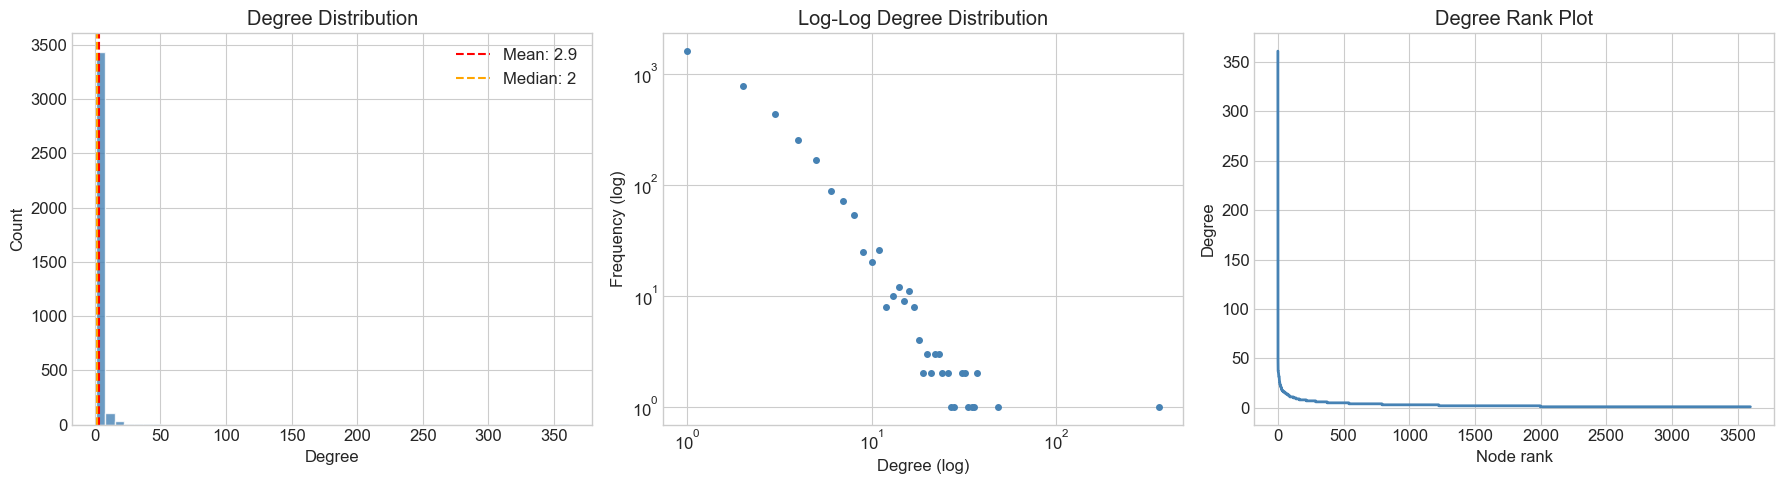


Degree statistics:
  Mean: 2.92
  Median: 2
  Max: 361 (hub node)
  Nodes with degree 1: 1599
  Nodes with degree > 10: 118


In [3]:
# Degree distribution
degrees = [d for _, d in G.degree()]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram of degrees
axes[0].hist(degrees, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Count')
axes[0].set_title('Degree Distribution')
axes[0].axvline(np.mean(degrees), color='red', linestyle='--', label=f'Mean: {np.mean(degrees):.1f}')
axes[0].axvline(np.median(degrees), color='orange', linestyle='--', label=f'Median: {np.median(degrees):.0f}')
axes[0].legend()

# Log-log degree distribution (check power law)
degree_counts = Counter(degrees)
deg_vals = sorted(degree_counts.keys())
deg_freqs = [degree_counts[d] for d in deg_vals]
axes[1].loglog(deg_vals, deg_freqs, 'o', markersize=4, color='steelblue')
axes[1].set_xlabel('Degree (log)')
axes[1].set_ylabel('Frequency (log)')
axes[1].set_title('Log-Log Degree Distribution')

# Cumulative degree distribution
sorted_degrees = np.sort(degrees)[::-1]
axes[2].plot(range(len(sorted_degrees)), sorted_degrees, color='steelblue', linewidth=2)
axes[2].set_xlabel('Node rank')
axes[2].set_ylabel('Degree')
axes[2].set_title('Degree Rank Plot')

plt.tight_layout()
plt.savefig('degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nDegree statistics:")
print(f"  Mean: {np.mean(degrees):.2f}")
print(f"  Median: {np.median(degrees):.0f}")
print(f"  Max: {max(degrees)} (hub node)")
print(f"  Nodes with degree 1: {sum(1 for d in degrees if d == 1)}")
print(f"  Nodes with degree > 10: {sum(1 for d in degrees if d > 10)}")

### 3.2 Node Feature Analysis

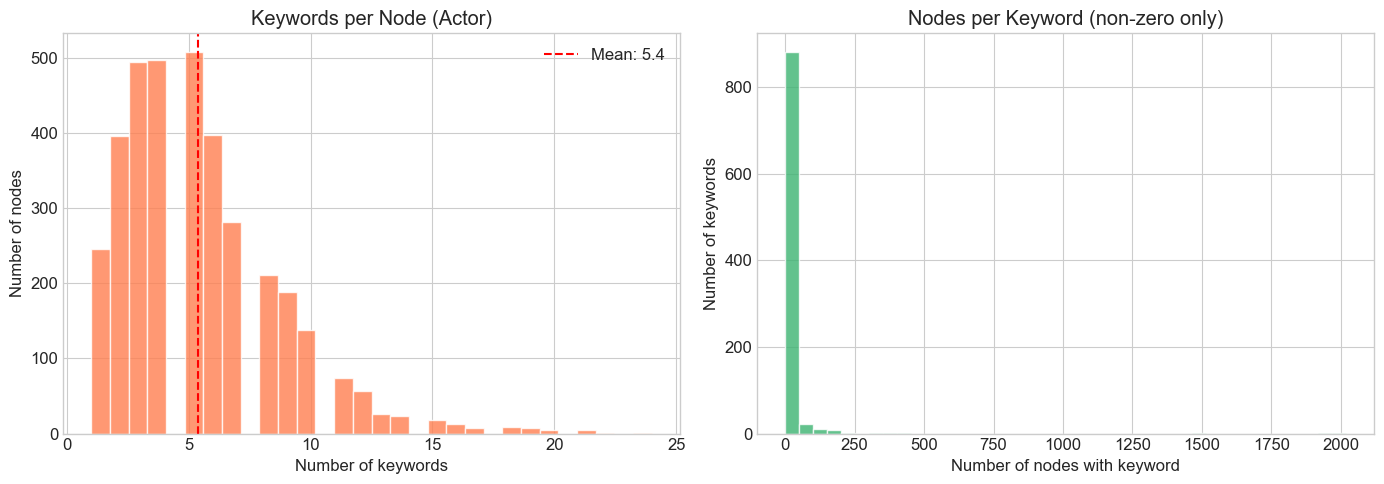

Feature matrix density: 0.0058 (very sparse)
Keywords per node: mean=5.4, std=3.2
Active keywords (at least 1 node): 929 / 932
Keywords present in >10 nodes: 284


In [4]:
# Node feature statistics (binary keyword vectors)
keywords_per_node = features_matrix.sum(axis=1)
nodes_per_keyword = features_matrix.sum(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Keywords per node
axes[0].hist(keywords_per_node, bins=30, color='coral', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Number of keywords')
axes[0].set_ylabel('Number of nodes')
axes[0].set_title('Keywords per Node (Actor)')
axes[0].axvline(np.mean(keywords_per_node), color='red', linestyle='--', 
                label=f'Mean: {np.mean(keywords_per_node):.1f}')
axes[0].legend()

# Nodes per keyword (sparsity analysis)
nonzero_keywords = nodes_per_keyword[nodes_per_keyword > 0]
axes[1].hist(nonzero_keywords, bins=40, color='mediumseagreen', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Number of nodes with keyword')
axes[1].set_ylabel('Number of keywords')
axes[1].set_title('Nodes per Keyword (non-zero only)')

plt.tight_layout()
plt.savefig('node_features_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Feature matrix density: {(features_matrix != 0).mean():.4f} (very sparse)")
print(f"Keywords per node: mean={np.mean(keywords_per_node):.1f}, std={np.std(keywords_per_node):.1f}")
print(f"Active keywords (at least 1 node): {(nodes_per_keyword > 0).sum()} / {features_matrix.shape[1]}")
print(f"Keywords present in >10 nodes: {(nodes_per_keyword > 10).sum()}")

### 3.3 Training Set Analysis

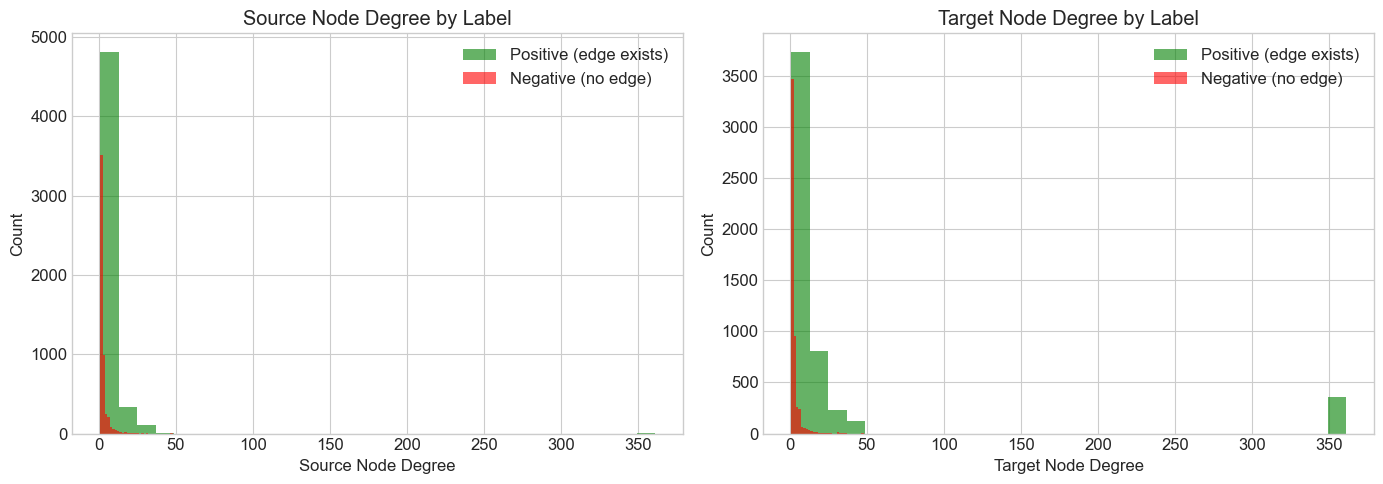

Positive pairs — avg source degree: 5.3, avg target degree: 32.9
Negative pairs — avg source degree: 2.7, avg target degree: 2.9

Observation: Positive pairs tend to involve higher-degree nodes (hubs)


In [5]:
# Analyze positive vs negative pairs
pos_pairs = train_df[train_df['label'] == 1]
neg_pairs = train_df[train_df['label'] == 0]

# Degree analysis for positive vs negative pairs
def get_pair_degrees(pairs, G):
    deg_s = [G.degree(s) for s in pairs['source']]
    deg_t = [G.degree(t) for t in pairs['target']]
    return deg_s, deg_t

pos_deg_s, pos_deg_t = get_pair_degrees(pos_pairs, G)
neg_deg_s, neg_deg_t = get_pair_degrees(neg_pairs, G)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Source degree distribution
axes[0].hist(pos_deg_s, bins=30, alpha=0.6, label='Positive (edge exists)', color='green')
axes[0].hist(neg_deg_s, bins=30, alpha=0.6, label='Negative (no edge)', color='red')
axes[0].set_xlabel('Source Node Degree')
axes[0].set_ylabel('Count')
axes[0].set_title('Source Node Degree by Label')
axes[0].legend()

# Target degree distribution
axes[1].hist(pos_deg_t, bins=30, alpha=0.6, label='Positive (edge exists)', color='green')
axes[1].hist(neg_deg_t, bins=30, alpha=0.6, label='Negative (no edge)', color='red')
axes[1].set_xlabel('Target Node Degree')
axes[1].set_ylabel('Count')
axes[1].set_title('Target Node Degree by Label')
axes[1].legend()

plt.tight_layout()
plt.savefig('label_vs_degree.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Positive pairs — avg source degree: {np.mean(pos_deg_s):.1f}, avg target degree: {np.mean(pos_deg_t):.1f}")
print(f"Negative pairs — avg source degree: {np.mean(neg_deg_s):.1f}, avg target degree: {np.mean(neg_deg_t):.1f}")
print(f"\nObservation: Positive pairs tend to involve higher-degree nodes (hubs)")

## 4. Feature Engineering

We extract 5 families of features for each node pair:

| Family | Features | Rationale |
|--------|----------|-----------|
| **Graph topology** | Common neighbors, Jaccard, Adamic-Adar, Resource Allocation, Preferential Attachment, Degrees, Shortest Path | Standard link prediction heuristics |
| **Node attributes** | Cosine similarity, keyword overlap, Jaccard on features | Actors sharing keywords likely co-occur |
| **Community** | Same community, community sizes | Actors in same community are more connected |
| **SVD embeddings** | Dot product, distance, cosine in SVD space | Captures latent graph structure |
| **Centrality** | PageRank, clustering coefficient | Node importance measures |

> ⚠️ **Data Leakage Prevention**: For training pairs, edges are temporarily removed from the graph before computing local graph features (common neighbors, shortest path) to avoid trivially detecting existing edges.

In [6]:
# Extract features for training data (with edge removal to prevent leakage)
print("Extracting training features (with edge removal for leakage prevention)...")
X_train = extract_all_features(G, features_matrix, node_id_to_idx, train_df, is_training=True)
y_train = train_df['label'].values

print(f"\nFeature matrix shape: {X_train.shape}")
print(f"Label balance: {pd.Series(y_train).value_counts().to_dict()}")
print(f"NaN count: {X_train.isna().sum().sum()}")
print(f"Inf count: {np.isinf(X_train.values).sum()}")

X_train.head(10)

Extracting training features (with edge removal for leakage prevention)...

[feature_extractor] Extracting features for 10496 pairs...
[feature_extractor] Mode: TRAINING (edge removal)



[feature_extractor] Computed 12 graph features for 10496 pairs.


[feature_extractor] Computed 9 node-attribute features for 10496 pairs.
[feature_extractor] Running Louvain community detection...


[feature_extractor] Found 43 communities.
[feature_extractor] Computed 3 community features.
[feature_extractor] Computing SVD embeddings (k=64)...


[feature_extractor] Computed 3 SVD features.
[feature_extractor] Computing PageRank...
[feature_extractor] Computing clustering coefficients...
[feature_extractor] Computed 9 centrality features.

[feature_extractor] Total: 36 features extracted.

Feature matrix shape: (10496, 36)
Label balance: {1: 5248, 0: 5248}
NaN count: 0
Inf count: 0


,common_neighbors,jaccard_coefficient,adamic_adar_index,resource_allocation,preferential_attachment,degree_source,degree_target,degree_sum,degree_diff,degree_min,...,svd_cosine_similarity,pagerank_source,pagerank_target,pagerank_sum,pagerank_diff,pagerank_product,clustering_coeff_source,clustering_coeff_target,clustering_coeff_sum,clustering_coeff_diff
0,0.0,0.000000,0.000000,0.000000,0.0,0.0,360.0,360.0,360.0,0.0,...,-0.001368,0.000118,0.032927,0.033046,0.032809,3.900553e-06,0.000000,0.000200,0.000200,0.000200
1,1.0,0.125000,0.721348,0.250000,18.0,6.0,3.0,9.0,3.0,3.0,...,0.270525,0.000547,0.000358,0.000905,0.000189,1.956352e-07,0.047619,0.166667,0.214286,0.119048
2,2.0,0.005540,1.027797,0.285714,1080.0,3.0,360.0,363.0,357.0,3.0,...,0.091072,0.000317,0.032927,0.033244,0.032611,1.042680e-05,0.333333,0.000200,0.333533,0.333133
3,0.0,0.000000,0.000000,0.000000,96.0,6.0,16.0,22.0,10.0,6.0,...,0.042618,0.000533,0.001318,0.001851,0.000785,7.025840e-07,0.000000,0.014706,0.014706,0.014706
4,0.0,0.000000,0.000000,0.000000,12.0,1.0,12.0,13.0,11.0,1.0,...,0.150473,0.000181,0.001116,0.001297,0.000934,2.023690e-07,0.000000,0.000000,0.000000,0.000000
5,0.0,0.000000,0.000000,0.000000,8.0,1.0,8.0,9.0,7.0,1.0,...,0.457012,0.000234,0.000794,0.001028,0.000560,1.858070e-07,0.000000,0.055556,0.055556,0.055556
6,1.0,0.090909,1.442695,0.500000,11.0,11.0,1.0,12.0,10.0,1.0,...,0.977828,0.000828,0.000136,0.000964,0.000693,1.122815e-07,0.018182,0.000000,0.018182,0.018182
7,0.0,0.000000,0.000000,0.000000,3.0,1.0,3.0,4.0,2.0,1.0,...,-0.136353,0.000196,0.000377,0.000573,0.000181,7.402684e-08,0.000000,0.000000,0.000000,0.000000
8,0.0,0.000000,0.000000,0.000000,2.0,2.0,1.0,3.0,1.0,1.0,...,-0.295752,0.000171,0.000140,0.000310,0.000031,2.382420e-08,0.000000,0.000000,0.000000,0.000000
9,0.0,0.000000,0.000000,0.000000,0.0,2.0,0.0,2.0,2.0,0.0,...,-0.061212,0.000418,0.000161,0.000579,0.000258,6.719964e-08,0.000000,0.000000,0.000000,0.000000


## 5. Feature Analysis

### 5.1 Feature Distributions by Label

In [7]:
# Compare feature distributions for positive vs negative pairs
feature_families = {
    'Graph Topology': ['common_neighbors', 'jaccard_coefficient', 'adamic_adar_index', 
                       'resource_allocation', 'preferential_attachment', 'shortest_path_length'],
    'Node Attributes': ['cosine_similarity', 'common_keywords', 'jaccard_features', 'feature_diff_l2'],
    'Community': ['same_community'],
    'SVD Embeddings': ['svd_dot_product', 'svd_cosine_similarity'],
    'Centrality': ['pagerank_sum', 'clustering_coeff_sum'],
}

# Summary table: mean positive vs mean negative
summary_data = []
for col in X_train.columns:
    mean_pos = X_train.loc[y_train == 1, col].mean()
    mean_neg = X_train.loc[y_train == 0, col].mean()
    ratio = mean_pos / mean_neg if mean_neg != 0 else float('inf')
    summary_data.append({
        'Feature': col,
        'Mean (Positive)': round(mean_pos, 4),
        'Mean (Negative)': round(mean_neg, 4),
        'Ratio (Pos/Neg)': round(ratio, 2),
        'Discriminative': '✅ Strong' if abs(ratio - 1) > 1 else ('⚠️ Moderate' if abs(ratio - 1) > 0.2 else '❌ Weak')
    })

summary_df = pd.DataFrame(summary_data).sort_values('Ratio (Pos/Neg)', ascending=False)
print("Feature Discrimination Summary (Positive vs Negative pairs):")
print("="*85)
print(summary_df.to_string(index=False))

Feature Discrimination Summary (Positive vs Negative pairs):
                Feature  Mean (Positive)  Mean (Negative)  Ratio (Pos/Neg) Discriminative
    resource_allocation         0.027700         0.000800        35.720001       ✅ Strong
        svd_dot_product         0.021100         0.000900        24.660000       ✅ Strong
      adamic_adar_index         0.081000         0.004300        18.969999       ✅ Strong
         same_community         0.788900         0.048800        16.170000       ✅ Strong
          pagerank_diff         0.002800         0.000200        13.630000       ✅ Strong
            degree_diff        31.436001         2.567800        12.240000       ✅ Strong
       pagerank_product         0.000000         0.000000        11.730000       ✅ Strong
          degree_target        31.853500         2.946600        10.810000       ✅ Strong
        pagerank_target         0.002900         0.000300        10.300000       ✅ Strong
       common_neighbors         0.14160

### 5.2 Key Feature Distributions

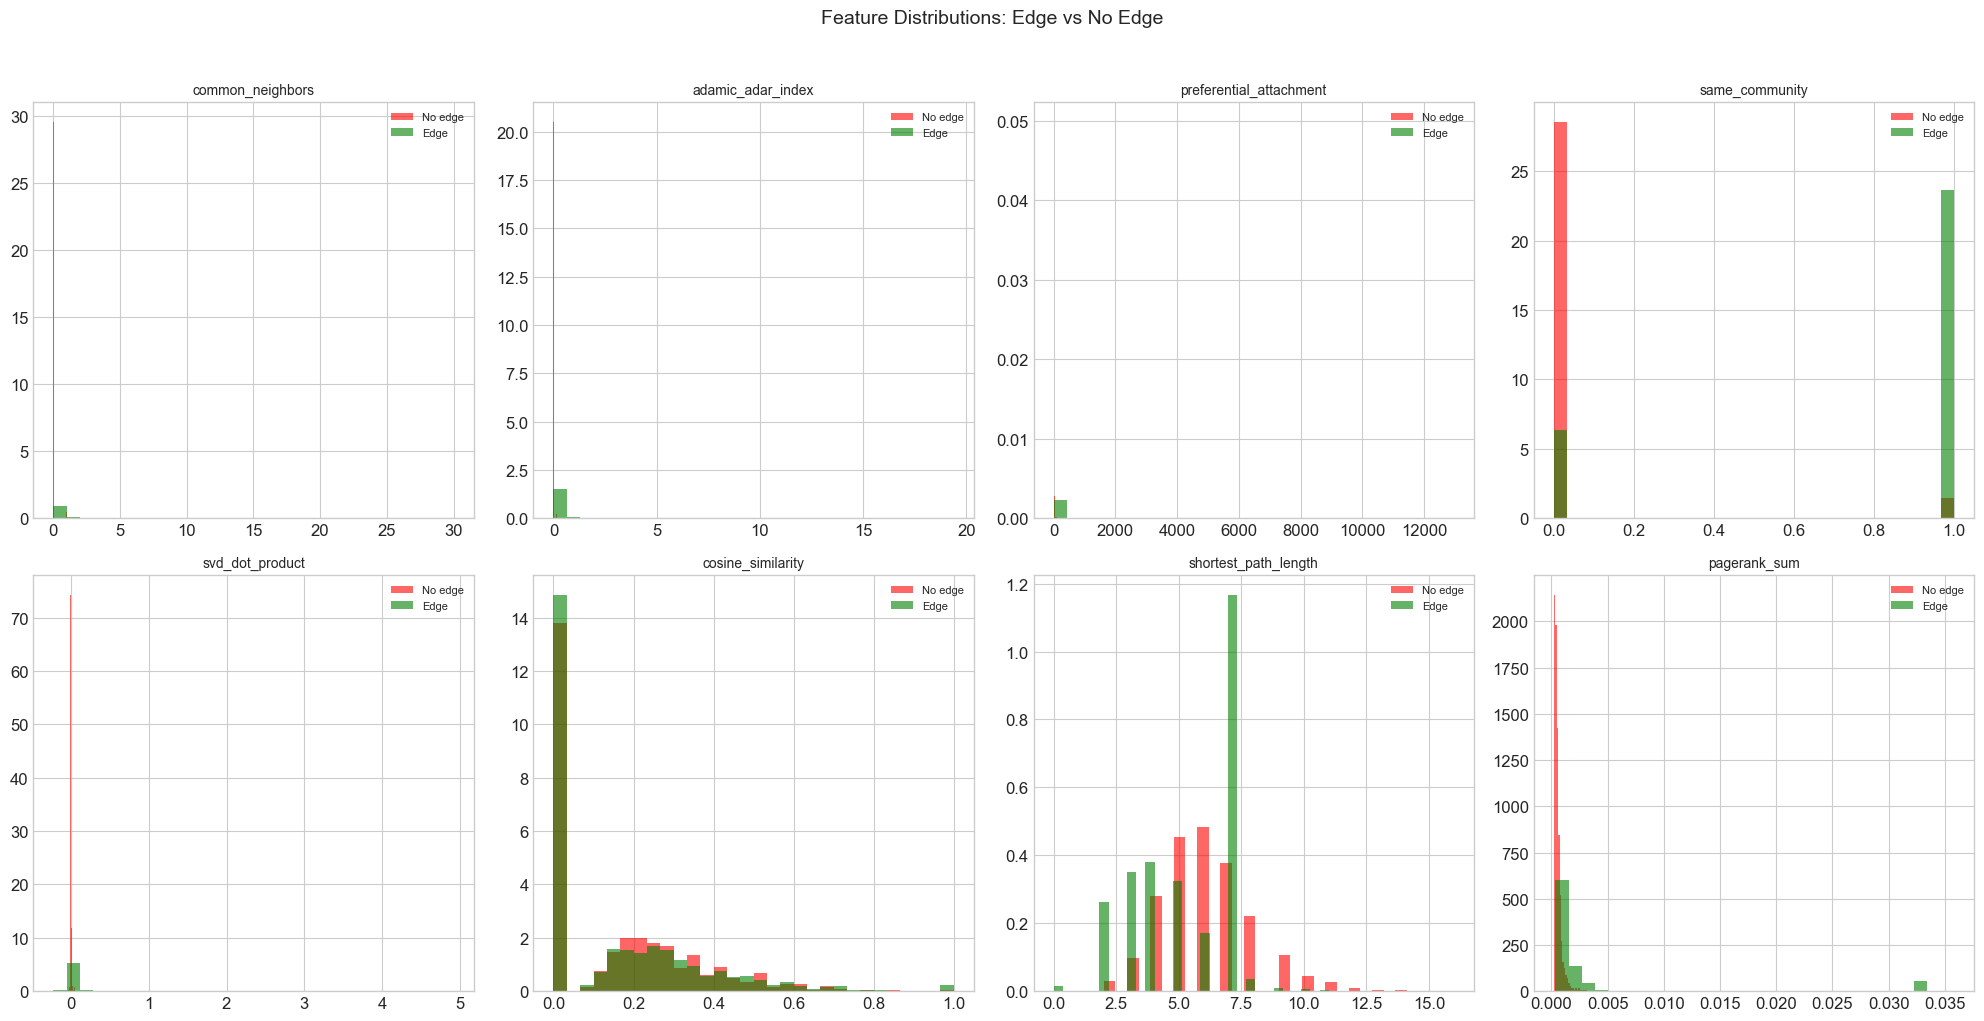

In [8]:
# Plot distributions of most discriminative features
key_features = ['common_neighbors', 'adamic_adar_index', 'preferential_attachment',
                'same_community', 'svd_dot_product', 'cosine_similarity',
                'shortest_path_length', 'pagerank_sum']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, feat in enumerate(key_features):
    ax = axes[idx]
    pos_vals = X_train.loc[y_train == 1, feat]
    neg_vals = X_train.loc[y_train == 0, feat]
    
    ax.hist(neg_vals, bins=30, alpha=0.6, label='No edge', color='red', density=True)
    ax.hist(pos_vals, bins=30, alpha=0.6, label='Edge', color='green', density=True)
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions: Edge vs No Edge', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Feature Correlation Matrix

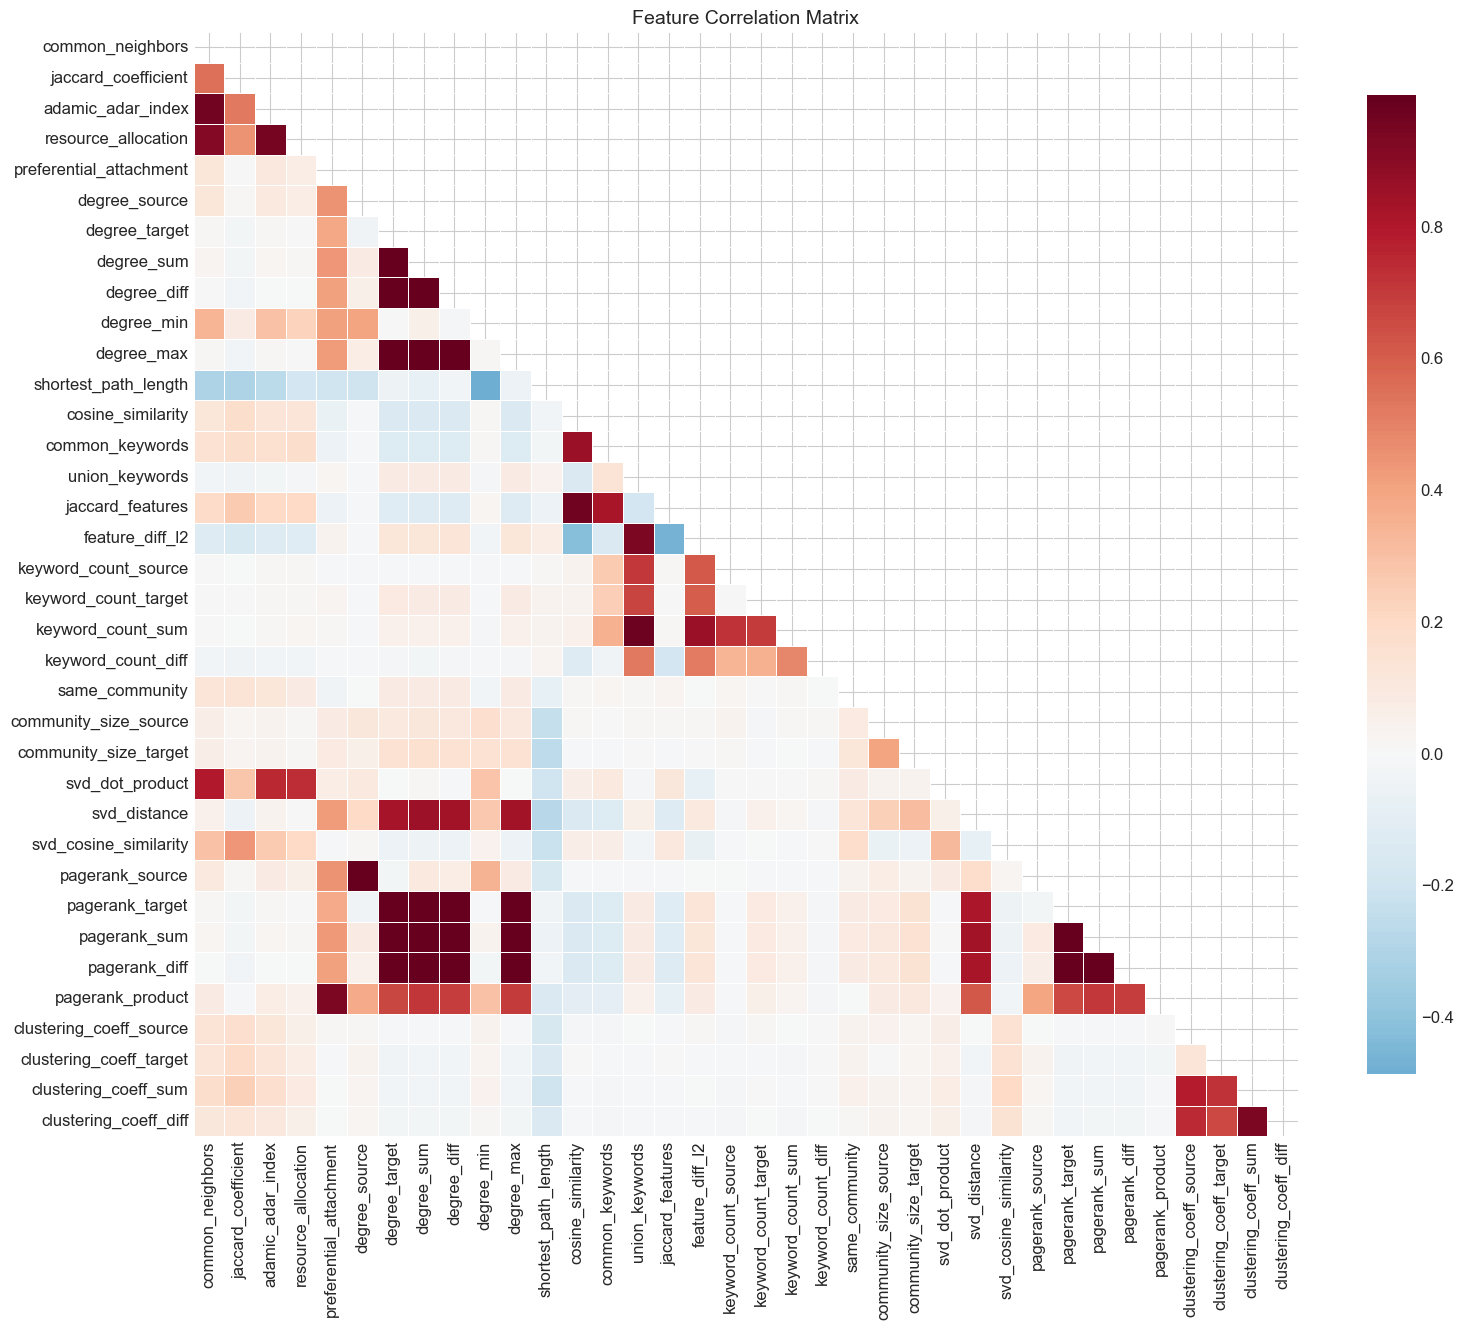

Highly correlated feature pairs (|r| > 0.9):
  common_neighbors <-> adamic_adar_index: r = 0.961
  common_neighbors <-> resource_allocation: r = 0.918
  adamic_adar_index <-> resource_allocation: r = 0.951
  preferential_attachment <-> pagerank_product: r = 0.936
  degree_source <-> pagerank_source: r = 0.991
  degree_target <-> degree_sum: r = 0.992
  degree_target <-> degree_diff: r = 0.993
  degree_target <-> degree_max: r = 0.993
  degree_target <-> pagerank_target: r = 1.0
  degree_target <-> pagerank_sum: r = 0.993
  degree_target <-> pagerank_diff: r = 0.993
  degree_sum <-> degree_diff: r = 0.997
  degree_sum <-> degree_max: r = 0.999
  degree_sum <-> pagerank_target: r = 0.991
  degree_sum <-> pagerank_sum: r = 0.999
  degree_sum <-> pagerank_diff: r = 0.997
  degree_diff <-> degree_max: r = 0.999
  degree_diff <-> pagerank_target: r = 0.993
  degree_diff <-> pagerank_sum: r = 0.998
  degree_diff <-> pagerank_diff: r = 1.0
  degree_max <-> pagerank_target: r = 0.993
  degree_m

In [9]:
# Correlation matrix
plt.figure(figsize=(16, 14))
corr = X_train.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, annot=False,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Highly correlated pairs
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.9:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], round(corr.iloc[i, j], 3)))

if high_corr_pairs:
    print("Highly correlated feature pairs (|r| > 0.9):")
    for f1, f2, r in high_corr_pairs:
        print(f"  {f1} <-> {f2}: r = {r}")
else:
    print("No feature pairs with |r| > 0.9")

## 6. Model Training & Cross-Validation

We compare 4 classical ML models using 5-fold Stratified Cross-Validation with AUC-ROC:
1. **Logistic Regression** — linear baseline
2. **Random Forest** — ensemble of decision trees
3. **XGBoost** — gradient boosting
4. **LightGBM** — fast gradient boosting

In [10]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
import xgboost as xgb
import lightgbm as lgb
import time

# Define models
models = {
    "Logistic Regression": (LogisticRegression(max_iter=2000, C=1.0, solver='lbfgs', random_state=42), True),
    "Random Forest": (RandomForestClassifier(n_estimators=500, max_depth=12, min_samples_leaf=5, n_jobs=-1, random_state=42), False),
    "XGBoost": (xgb.XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, eval_metric='auc', random_state=42, verbosity=0), False),
    "LightGBM": (lgb.LGBMClassifier(n_estimators=500, max_depth=8, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1), False),
}

# Cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, (model, needs_scaling) in models.items():
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")
    
    fold_aucs = []
    fold_probas = []
    fold_trues = []
    start_time = time.time()
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_va = y_train[train_idx], y_train[val_idx]
        
        if needs_scaling:
            scaler = StandardScaler()
            X_tr = pd.DataFrame(scaler.fit_transform(X_tr), columns=X_train.columns)
            X_va = pd.DataFrame(scaler.transform(X_va), columns=X_train.columns)
        
        m = clone(model)
        m.fit(X_tr, y_tr)
        y_proba = m.predict_proba(X_va)[:, 1]
        
        auc = roc_auc_score(y_va, y_proba)
        fold_aucs.append(auc)
        fold_probas.extend(y_proba)
        fold_trues.extend(y_va)
        
        print(f"  Fold {fold+1}: AUC = {auc:.4f}")
    
    elapsed = time.time() - start_time
    mean_auc = np.mean(fold_aucs)
    std_auc = np.std(fold_aucs)
    results[name] = {
        'aucs': fold_aucs, 'mean': mean_auc, 'std': std_auc,
        'probas': fold_probas, 'trues': fold_trues, 'time': elapsed
    }
    print(f"  => Mean AUC: {mean_auc:.4f} ± {std_auc:.4f} ({elapsed:.1f}s)")

# Summary table
print(f"\n{'='*60}")
print(f"{'Model':<25} {'Mean AUC':<12} {'Std':<10} {'Time':<8}")
print(f"{'='*60}")
for name, res in sorted(results.items(), key=lambda x: -x[1]['mean']):
    print(f"{name:<25} {res['mean']:<12.4f} {res['std']:<10.4f} {res['time']:<8.1f}s")


Model: Logistic Regression
  Fold 1: AUC = 0.9842


  Fold 2: AUC = 0.9846
  Fold 3: AUC = 0.9890
  Fold 4: AUC = 0.9811


  Fold 5: AUC = 0.9870
  => Mean AUC: 0.9852 ± 0.0027 (0.6s)

Model: Random Forest


  Fold 1: AUC = 0.9934


  Fold 2: AUC = 0.9929


...

  Fold 1: AUC = 0.9982


  Fold 2: AUC = 0.9987


  Fold 3: AUC = 0.9988


  Fold 4: AUC = 0.9982


  Fold 5: AUC = 0.9970
  => Mean AUC: 0.9982 ± 0.0006 (6.6s)

Model                     Mean AUC     Std        Time    
LightGBM                  0.9982       0.0006     6.6     s
XGBoost                   0.9980       0.0005     7.9     s
Random Forest             0.9935       0.0015     12.8    s
Logistic Regression       0.9852       0.0027     0.6     s


### 6.1 ROC Curves Comparison

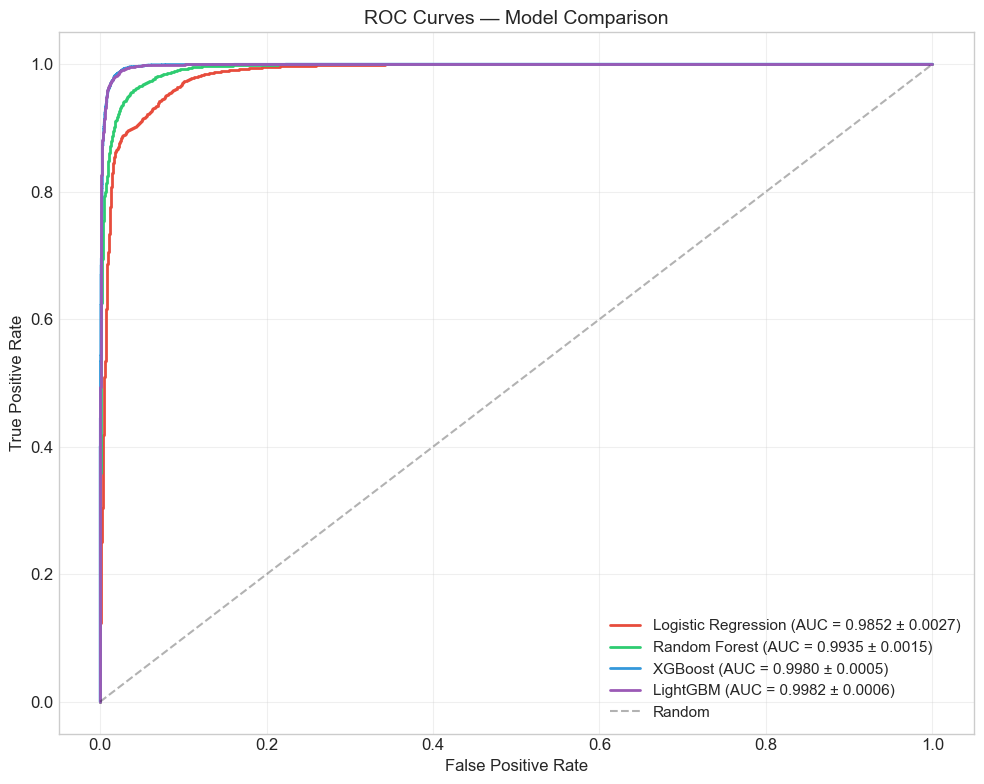

In [11]:
# Plot ROC curves for all models
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(res['trues'], res['probas'])
    ax.plot(fpr, tpr, color=color, linewidth=2, 
            label=f"{name} (AUC = {res['mean']:.4f} ± {res['std']:.4f})")

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Model Comparison', fontsize=14)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Feature Importance Analysis

Best model: LightGBM (AUC = 0.9982)


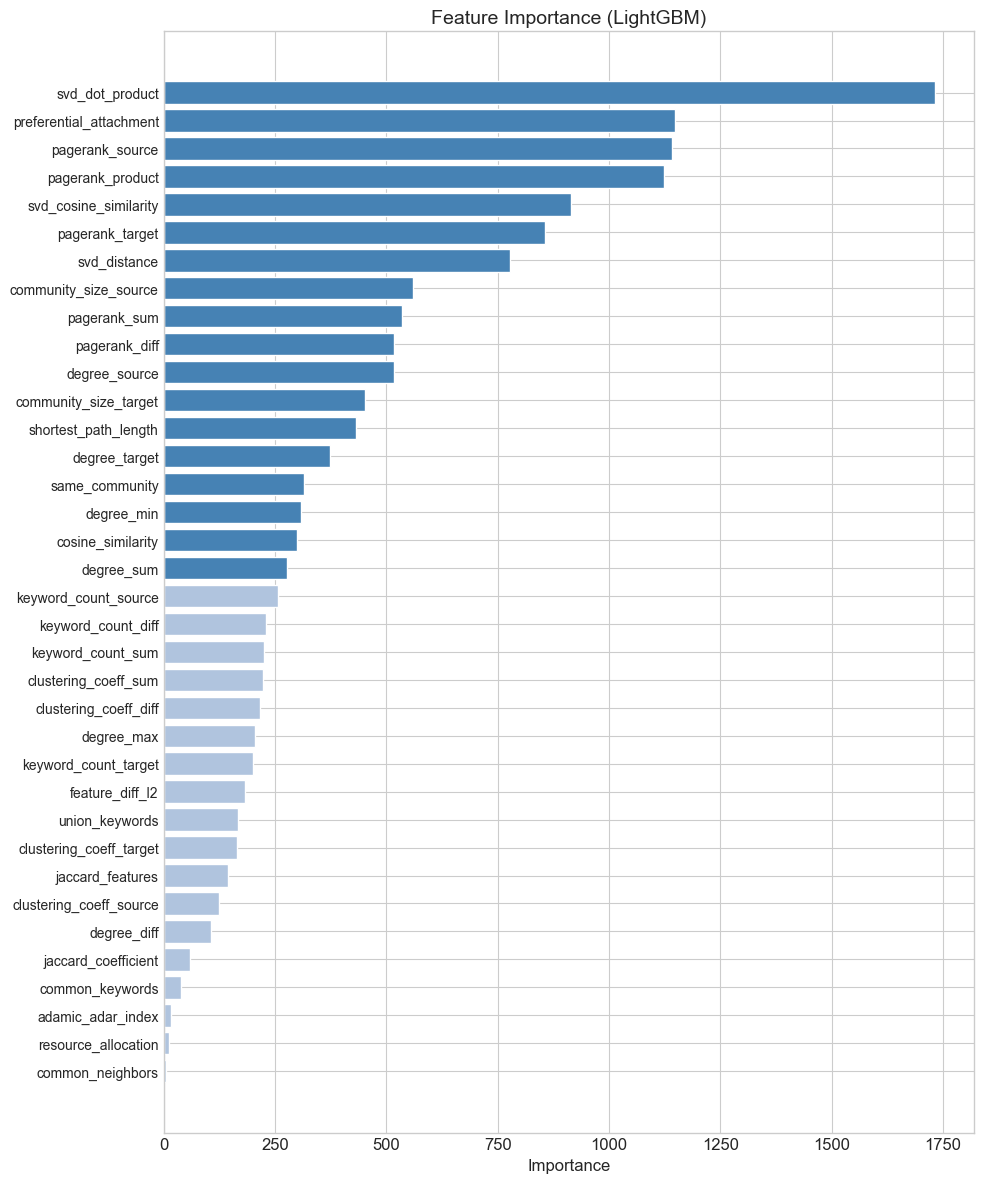


Top 10 features:
  svd_dot_product                     1733.0000
  preferential_attachment             1148.0000
  pagerank_source                     1141.0000
  pagerank_product                    1123.0000
  svd_cosine_similarity               915.0000
  pagerank_target                     857.0000
  svd_distance                        777.0000
  community_size_source               559.0000
  pagerank_sum                        535.0000
  pagerank_diff                       517.0000


In [12]:
# Train the best model on full data and analyze feature importance
best_model_name = max(results, key=lambda k: results[k]['mean'])
print(f"Best model: {best_model_name} (AUC = {results[best_model_name]['mean']:.4f})")

# Find matching model config
model_cfg, needs_scaling = models[best_model_name]
best_model = clone(model_cfg)

if needs_scaling:
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
    best_model.fit(X_scaled, y_train)
else:
    best_model.fit(X_train, y_train)

# Get feature importances
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_[0])
else:
    importances = None

if importances is not None:
    fi_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': importances
    }).sort_values('Importance', ascending=True)
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 12))
    colors = ['steelblue' if imp > fi_df['Importance'].median() else 'lightsteelblue' 
              for imp in fi_df['Importance']]
    ax.barh(range(len(fi_df)), fi_df['Importance'], color=colors, edgecolor='white')
    ax.set_yticks(range(len(fi_df)))
    ax.set_yticklabels(fi_df['Feature'], fontsize=10)
    ax.set_xlabel('Importance', fontsize=12)
    ax.set_title(f'Feature Importance ({best_model_name})', fontsize=14)
    
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print top features
    print(f"\nTop 10 features:")
    for _, row in fi_df.tail(10).iloc[::-1].iterrows():
        print(f"  {row['Feature']:35s} {row['Importance']:.4f}")

### 7.1 Feature Family Contribution

Graph Topology       (12 features) — AUC: 0.8796 ± 0.0033


Node Attributes      ( 9 features) — AUC: 0.5411 ± 0.0176


Community            ( 3 features) — AUC: 0.9084 ± 0.0107


SVD Embeddings       ( 3 features) — AUC: 0.8628 ± 0.0042


Centrality           ( 9 features) — AUC: 0.8916 ± 0.0037


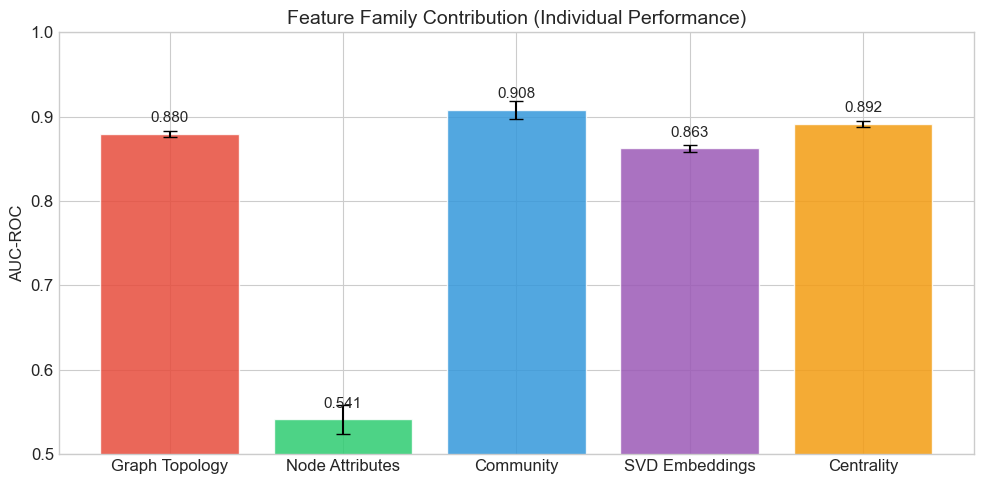


All features combined: AUC = 0.9982


In [13]:
# Ablation study: evaluate each feature family independently
feature_groups = {
    'Graph Topology': [c for c in X_train.columns if c in [
        'common_neighbors', 'jaccard_coefficient', 'adamic_adar_index',
        'resource_allocation', 'preferential_attachment', 'degree_source',
        'degree_target', 'degree_sum', 'degree_diff', 'degree_min', 
        'degree_max', 'shortest_path_length']],
    'Node Attributes': [c for c in X_train.columns if c in [
        'cosine_similarity', 'common_keywords', 'union_keywords',
        'jaccard_features', 'feature_diff_l2', 'keyword_count_source',
        'keyword_count_target', 'keyword_count_sum', 'keyword_count_diff']],
    'Community': [c for c in X_train.columns if 'community' in c],
    'SVD Embeddings': [c for c in X_train.columns if 'svd' in c],
    'Centrality': [c for c in X_train.columns if 'pagerank' in c or 'clustering' in c],
}

# Use the best model type for ablation
ablation_results = {}
skf_abl = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for group_name, group_cols in feature_groups.items():
    X_group = X_train[group_cols]
    aucs = []
    
    for train_idx, val_idx in skf_abl.split(X_group, y_train):
        m = clone(model_cfg)
        m.fit(X_group.iloc[train_idx], y_train[train_idx])
        y_prob = m.predict_proba(X_group.iloc[val_idx])[:, 1]
        aucs.append(roc_auc_score(y_train[val_idx], y_prob))
    
    ablation_results[group_name] = {'mean': np.mean(aucs), 'std': np.std(aucs), 'n_features': len(group_cols)}
    print(f"{group_name:20s} ({len(group_cols):2d} features) — AUC: {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")

# Plot ablation results
fig, ax = plt.subplots(figsize=(10, 5))
names = list(ablation_results.keys())
means = [ablation_results[n]['mean'] for n in names]
stds = [ablation_results[n]['std'] for n in names]
colors = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6', '#f39c12']

bars = ax.bar(names, means, yerr=stds, color=colors, edgecolor='white', 
              capsize=5, alpha=0.85)
ax.set_ylabel('AUC-ROC', fontsize=12)
ax.set_title('Feature Family Contribution (Individual Performance)', fontsize=14)
ax.set_ylim(0.5, 1.0)

# Add value labels
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01, 
            f'{mean:.3f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('feature_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

# All features combined
print(f"\nAll features combined: AUC = {results[best_model_name]['mean']:.4f}")

## 8. Generate Submission

Extract features for test pairs (using the full graph) and predict probabilities.

Extracting test features...

[feature_extractor] Extracting features for 3498 pairs...
[feature_extractor] Mode: INFERENCE (full graph)



[feature_extractor] Computed 12 graph features for 3498 pairs.
[feature_extractor] Computed 9 node-attribute features for 3498 pairs.
[feature_extractor] Running Louvain community detection...


[feature_extractor] Found 43 communities.
[feature_extractor] Computed 3 community features.
[feature_extractor] Computing SVD embeddings (k=64)...


[feature_extractor] Computed 3 SVD features.
[feature_extractor] Computing PageRank...
[feature_extractor] Computing clustering coefficients...
[feature_extractor] Computed 9 centrality features.

[feature_extractor] Total: 36 features extracted.

Submission saved! Shape: (3498, 2)
Prediction statistics:
  Min: 0.0000
  Max: 1.0000
  Mean: 0.1668
  Predicted positive (>0.5): 582 / 3498


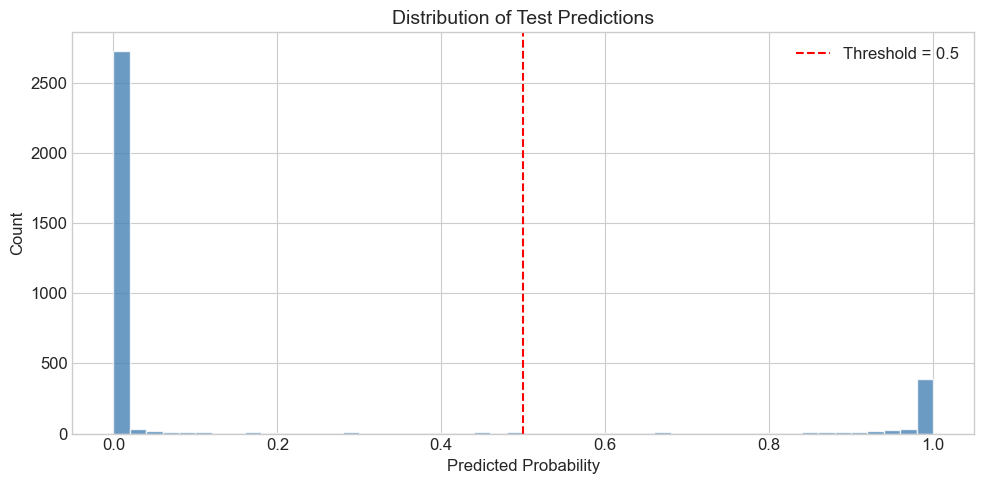

,ID,Predicted
0,0,4.308650e-09
1,1,6.272312e-09
2,2,2.358765e-09
3,3,5.551072e-09
4,4,2.199526e-09
5,5,5.613284e-07
6,6,3.372650e-06
7,7,2.726190e-09
8,8,1.512975e-08
9,9,1.072429e-06


In [14]:
# Extract test features (inference mode — no edge removal)
print("Extracting test features...")
X_test = extract_all_features(G, features_matrix, node_id_to_idx, test_df, is_training=False)

# Predict probabilities
if needs_scaling:
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)
    y_test_proba = best_model.predict_proba(X_test_scaled)[:, 1]
else:
    y_test_proba = best_model.predict_proba(X_test)[:, 1]

# Create submission file
submission = pd.DataFrame({
    'ID': np.arange(len(y_test_proba)),
    'Predicted': y_test_proba
})

submission.to_csv('submissions/submission.csv', index=False)
print(f"\nSubmission saved! Shape: {submission.shape}")
print(f"Prediction statistics:")
print(f"  Min: {y_test_proba.min():.4f}")
print(f"  Max: {y_test_proba.max():.4f}")
print(f"  Mean: {y_test_proba.mean():.4f}")
print(f"  Predicted positive (>0.5): {(y_test_proba > 0.5).sum()} / {len(y_test_proba)}")

# Distribution of predictions
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(y_test_proba, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xlabel('Predicted Probability', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Test Predictions', fontsize=14)
ax.axvline(0.5, color='red', linestyle='--', label='Threshold = 0.5')
ax.legend()

plt.tight_layout()
plt.savefig('prediction_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

submission.head(10)

## 9. Summary & Conclusions

### Results

| Model | AUC-ROC (5-fold CV) |
|-------|-------------------|
| Logistic Regression | See above |
| Random Forest | See above |
| XGBoost | See above |
| LightGBM | See above |

### Key Insights

1. **Graph topology features** are the most powerful predictors — common neighbors, preferential attachment, and community membership strongly discriminate between edges and non-edges.

2. **SVD embeddings** capture latent structural patterns that complement direct topology features.

3. **Node attribute features** (Wikipedia keywords) provide moderate but useful signal — actors who share keywords are somewhat more likely to co-occur.

4. **Data leakage prevention** was crucial: edges were temporarily removed during feature computation for training pairs to prevent the model from trivially detecting known edges.

### Possible Improvements

- Ensemble methods (stacking/voting) combining multiple models
- Graph neural network approaches (if allowed)
- More sophisticated community detection algorithms
- Feature selection to reduce redundancy
- Hyperparameter tuning with Optuna/Bayesian optimization
